# Transit Anomaly Detection for Airport and Border Control Data

**Machine Learning Project — Academic Year 2025/26**
**Company brief:** Whitehall Reply — Project 2 *(Classical vs Multi-Agent anomaly detection)*

**Team members**    - Giulio D'Amico    - Alexis Mitracos
---

## Project scope

Border-control authorities and airport operators handle large volumes of passenger transits daily, with rich metadata attached to each event (timestamp, gate, route, nationality, document type, control outcome, alert flags). Today, anomaly detection on such data is mostly reactive. The goal of this project is to implement the same anomaly-detection system twice — once as a **classical pipeline** and once as a **multi-agent architecture** — and to produce a comparative analysis identifying the operational conditions under which each approach is preferable.

## Notebook Index

1. Setup and data loading
2. Data-quality audit
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis
6. Outlier analysis
7. Cross-dataset coverage
8. Feature engineering
9. Engineered features
10. Feature selection
11. Isolation Forest detector
12. Local Outlier Factor detector
13. Z-score detector and three-way consensus
14. Rule-based post-processing layer
15. Conclusions and next steps


## 1. Setup and data loading

### 1.1 Imports and plotting defaults

We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), `missingno` for missing-value diagnostics, `pycountry` for ISO country-code normalisation, and `re` for the regex-based date parsing used in the cleaning block. Plotting defaults are set globally so that every figure in the notebook shares the same style.


In [396]:
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import pycountry

from IPython.display import display

# Global plotting defaults
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

# Project palette
NAVY, STEEL, CORAL, GREEN = "#1A3764", "#4682B4", "#E8735A", "#27AE60"
PALETTE = [NAVY, STEEL, CORAL, GREEN, "#F4A261", "#2A9D8F", "#E76F51"]

# Reproducibility
RANDOM_STATE = 42

### 1.2 Reference mappings

The raw CSVs come in Italian, with inconsistent casing, typographic errors (e.g. `AREOPORTO`), and a mixture of Italianised and English spellings for countries, cities and airports. To feed the downstream pipeline with a clean English `snake_case` schema we rely on four curated dictionaries:

- `manual_mapping` — IT to EN column-name mapping; disambiguates duplicated columns (e.g. `Tipo_Documento` and `TIPO_DOCUMENTO` become `document_type` and `document_type2`) that are reconciled in section 2.3.
- `it_to_en` — Italian to English country names; consumed by `pycountry` to emit the ISO alpha-3 code of every departure country. Kosovo, which has no official ISO code, is hand-coded as `RKS`.
- `city_mapping` — Italianised city names mapped to their canonical English spelling.
- `iata_mapping` — a curated `IATA -> {city, airport}` lookup, used to back-fill missing city and airport descriptions in the Alarms dataset when the IATA column is populated but the free-text fields are not.
- `occurrences_map` — a mapping of the `OCCURRENCES` column in the Alarms dataset, which contains a mixture of numeric values and categorical labels (e.g. `>5`), to a clean numeric format that can be fed to the anomaly detectors.

All four dictionaries are embedded in the notebook (rather than imported from a configuration module) so that the notebook is fully self-contained, as required by the submission guidelines.


In [397]:
iata_mapping = {
    'ABJ': ('Abidjan', 'Felix Houphouet Boigny'),
    'ADB': ('Izmir', 'Adnan Menderes'),
    'ADD': ('Addis Ababa', 'Bole International'),
    'ADL': ('Adelaide', 'Adelaide International'),
    'AER': ('Sochi', 'Sochi International'),
    'AKL': ('Auckland', 'Auckland International'),
    'ALA': ('Almaty', 'Almaty International'),
    'ALG': ('Algiers', 'Houari Boumediene'),
    'AMD': ('Ahmedabad', 'Ahmedabad'),
    'AMM': ('Amman', 'Queen Alia International'),
    'ARN': ('Stockholm', 'Stockholm Arlanda'),
    'ASB': ('Ashgabat', 'Ashgabat'),
    'ASM': ('Asmara', 'Asmara International'),
    'ATL': ('Atlanta', 'Hartsfield-Jackson Atlanta International'),
    'AUH': ('Abu Dhabi', 'Abu Dhabi International'),
    'AYT': ('Antalya', 'Antalya'),
    'BAH': ('Manama', 'Bahrain International'),
    'BEG': ('Belgrade', 'Nikola Tesla'),
    'BEY': ('Beirut', 'Beirut-Rafic Hariri International'),
    'BFS': ('Belfast', 'Belfast International'),
    'BHX': ('Birmingham', 'Birmingham International'),
    'BKK': ('Bangkok', 'Suvarnabhumi International'),
    'BLR': ('Bangalore', 'Bangalore International'),
    'BNA': ('Nashville', 'Nashville International'),
    'BNE': ('Brisbane', 'Brisbane International'),
    'BOG': ('Bogota', 'Eldorado International'),
    'BOS': ('Boston', 'Logan International'),
    'BRS': ('Bristol', 'Bristol Airport'),
    'BSB': ('Brasilia', 'Presidente Juscelino Kubitschek'),
    'BUF': ('Buffalo', 'Buffalo Niagara International'),
    'CAI': ('Cairo', 'Cairo International'),
    'CAN': ('Guangzhou', 'Guangzhou Baiyun International'),
    'CEB': ('Cebu', 'Mactan-Cebu International'),
    'CGK': ('Jakarta', 'Soekarno-Hatta International'),
    'CLE': ('Cleveland', 'Hopkins International'),
    'CMN': ('Casablanca', 'Mohammed V International'),
    'CUN': ('Cancun', 'Cancun International'),
    'CVG': ('Cincinnati', 'Cincinnati/Northern Kentucky'),
    'DAR': ('Dar Es Salaam', 'Julius Nyerere International'),
    'DEL': ('New Delhi', 'Indira Gandhi International'),
    'DFW': ('Dallas-Fort Worth', 'Dallas/Fort Worth International'),
    'DMM': ('Dammam', 'King Fahd International'),
    'DOH': ('Doha', 'Hamad International'),
    'DPS': ('Denpasar', 'Ngurah Rai International'),
    'DSS': ('Dakar', 'Blaise Diagne International'),
    'DTW': ('Detroit', 'Detroit Metropolitan Wayne County'),
    'DUR': ('Durban', 'King Shaka International'),
    'DWC': ('Dubai', 'Al Maktoum International'),
    'DXB': ('Dubai', 'Dubai International'),
    'EDI': ('Edinburgh', 'Edinburgh Airport'),
    'ELQ': ('Buraidah', 'Gassim Regional'),
    'EMA': ('Derby', 'East Midlands'),
    'ESB': ('Ankara', 'Esenboga'),
    'EVN': ('Yerevan', 'Zvartnots International'),
    'EWR': ('Newark', 'Newark Liberty International'),
    'EZE': ('Buenos Aires', 'Ezeiza Ministro Pistarini'),
    'FEZ': ('Fes', 'Fes-Saiss'),
    'FIH': ('Kinshasa', "N'Djili International"),
    'FLL': ('Fort Lauderdale', 'Fort Lauderdale/Hollywood International'),
    'FRA': ('Frankfurt', 'Frankfurt International'),
    'FRU': ('Bishkek', 'Manas'),
    'FUK': ('Fukuoka', 'Fukuoka'),
    'GIG': ('Rio de Janeiro', 'Galeao-Antonio Carlos Jobim International'),
    'GLA': ('Glasgow', 'Glasgow International'),
    'GRU': ('Sao Paulo', 'Sao Paulo/Guarulhos International'),
    'GYD': ('Baku', 'Heydar Aliyev International'),
    'GZT': ('Gaziantep', 'Gaziantep'),
    'HAN': ('Hanoi', 'Noibai International'),
    'HGH': ('Hangzhou', 'Hangzhou Xiaoshan International'),
    'HKG': ('Hong Kong', 'Hong Kong International'),
    'HKT': ('Phuket', 'Phuket International'),
    'HND': ('Tokyo', 'Tokyo Haneda International'),
    'HRG': ('Hurghada', 'Hurghada International'),
    'IAD': ('Washington', 'Washington Dulles International'),
    'IAH': ('Houston', 'George Bush Intercontinental'),
    'ICN': ('Seoul', 'Incheon International'),
    'IFN': ('Isfahan', 'Isfahan International'),
    'IKA': ('Tehran', 'Imam Khomeini International'),
    'ISB': ('Islamabad', 'Islamabad International'),
    'IST': ('Istanbul', 'Istanbul Airport'),
    'JAX': ('Jacksonville', 'Jacksonville International'),
    'JED': ('Jeddah', 'King Abdulaziz International'),
    'JFK': ('New York', 'John F. Kennedy International'),
    'KBL': ('Kabul', 'Khwaja Rawash'),
    'KCH': ('Kuching', 'Kuching International'),
    'KIV': ('Chisinau', 'Chisinau International'),
    'KUL': ('Kuala Lumpur', 'Kuala Lumpur International'),
    'KUT': ('Kutaisi', 'Kutaisi International'),
    'KWI': ('Kuwait City', 'Kuwait International'),
    'KZN': ('Kazan', 'Kazan International'),
    'LAD': ('Luanda', '4 de Fevereiro'),
    'LAS': ('Las Vegas', 'McCarran International'),
    'LAX': ('Los Angeles', 'Los Angeles International'),
    'LCY': ('London', 'London City'),
    'LGW': ('London', 'London Gatwick'),
    'LHR': ('London', 'London Heathrow'),
    'LOS': ('Lagos', 'Murtala Muhammed'),
    'LPL': ('Liverpool', 'Liverpool John Lennon'),
    'LRM': ('La Romana', 'Casa de Campo International'),
    'LTN': ('London', 'London Luton'),
    'MAN': ('Manchester', 'Manchester Airport'),
    'MBA': ('Mombasa', 'Moi International'),
    'MCT': ('Muscat', 'Muscat International'),
    'MED': ('Madinah', 'Mohammad Bin Abdulaziz'),
    'MEL': ('Melbourne', 'Melbourne Tullamarine'),
    'MEX': ('Mexico City', 'Benito Juarez International'),
    'MHD': ('Mashad', 'Mashad'),
    'MIA': ('Miami', 'Miami International'),
    'MJI': ('Tripoli', 'Mitiga'),
    'MLE': ('Male', 'Velana International'),
    'MNL': ('Manila', 'Ninoy Aquino International'),
    'MPM': ('Maputo', 'Maputo International'),
    'MRU': ('Plaisance', 'Sir Seewoosagur Ramgoolam International'),
    'MYR': ('Myrtle Beach', 'Myrtle Beach International'),
    'NAV': ('Nevsehir', 'Nevsehir Kapadokya'),
    'NBO': ('Nairobi', 'Jomo Kenyatta International'),
    'NCL': ('Newcastle', 'Newcastle Airport'),
    'NOS': ('Nosy Be', 'Fascene'),
    'NRT': ('Tokyo', 'Narita International'),
    'NSI': ('Yaounde', 'Nsimalen International'),
    'ORD': ('Chicago', "Chicago O'Hare International"),
    'OUA': ('Ouagadougou', 'Ouagadougou'),
    'OXB': ('Bissau', 'Osvaldo Vieira International'),
    'PEK': ('Beijing', 'Beijing Capital International'),
    'PER': ('Perth', 'Perth International'),
    'PEW': ('Peshawar', 'Peshawar'),
    'PHL': ('Philadelphia', 'Philadelphia International'),
    'PKX': ('Beijing', 'Beijing Daxing International'),
    'POA': ('Porto Alegre', 'Salgado Filho'),
    'PRN': ('Pristina', 'Prishtina International'),
    'PVG': ('Shanghai', 'Shanghai Pudong International'),
    'PVR': ('Puerto Vallarta', 'Licenciado Gustavo Diaz Ordaz International'),
    'RAK': ('Marrakech', 'Menara'),
    'REC': ('Recife', 'Guararapes International'),
    'RMF': ('Marsa Alam', 'Marsa Alam International'),
    'RMO': ('Chisinau', 'Chisinau International'),
    'RUH': ('Riyadh', 'King Khaled International'),
    'SAW': ('Istanbul', 'Sabiha Gokcen'),
    'SCL': ('Santiago', 'Arturo Merino Benitez'),
    'SDU': ('Rio de Janeiro', 'Santos Dumont'),
    'SGN': ('Ho Chi Minh City', 'Tan Son Nhat International'),
    'SHJ': ('Sharjah', 'Sharjah International'),
    'SIN': ('Singapore', 'Changi'),
    'SJJ': ('Sarajevo', 'Sarajevo'),
    'SKG': ('Thessaloniki', 'Macedonia International'),
    'SKP': ('Skopje', 'Skopje International'),
    'SKT': ('Sialkot', 'Sialkot International'),
    'SMF': ('Sacramento', 'Sacramento International'),
    'SOF': ('Sofia', 'Sofia'),
    'SPX': ('Giza', 'Sphinx International'),
    'SSA': ('Salvador', 'Luis Eduardo Magalhaes'),
    'SSH': ('Sharm El Sheikh', 'Sharm El-Sheikh International'),
    'STN': ('London', 'London Stansted'),
    'SVO': ('Moscow', 'Sheremetyevo'),
    'SYD': ('Sydney', 'Kingsford Smith'),
    'SYR': ('Syracuse', 'Syracuse Hancock International'),
    'SYZ': ('Shiraz', 'Shiraz'),
    'SZX': ('Shenzhen', 'Shenzhen Baoan International'),
    'TAS': ('Tashkent', 'Tashkent International'),
    'TBS': ('Tbilisi', 'Tbilisi International'),
    'TFU': ('Chengdu', 'Tianfu International'),
    'TGD': ('Podgorica', 'Podgorica Airport'),
    'TIA': ('Tirana', 'Rinas Mother Teresa'),
    'TLV': ('Tel Aviv', 'Ben Gurion International'),
    'TNG': ('Tangier', 'Ibn Battouta'),
    'TPA': ('Tampa', 'Tampa International'),
    'TPE': ('Taipei', 'Taiwan Taoyuan International'),
    'TSA': ('Taipei', 'Taipei Songshan'),
    'TUN': ('Tunis', 'Tunis-Carthage'),
    'VKO': ('Moscow', 'Vnukovo'),
    'YEG': ('Edmonton', 'Edmonton International'),
    'YHZ': ('Halifax', 'Halifax International'),
    'YUL': ('Montreal', 'Montreal-Trudeau International'),
    'YVR': ('Vancouver', 'Vancouver International'),
    'YWG': ('Winnipeg', 'Winnipeg James Armstrong Richardson International'),
    'YYC': ('Calgary', 'Calgary International'),
    'YYZ': ('Toronto', 'Toronto Pearson International'),
    'ZNZ': ('Zanzibar', 'Abeid Amani Karume International'),
    'AGA': ('Agadir',       'Agadir Al Massira'),
    'ANU': ("St. John's",   'V.C. Bird International'),
    'ATQ': ('Amritsar',     'Sri Guru Ram Dass Jee International'),
    'BQH': ('London',       'London Biggin Hill'),
    'CGO': ('Zhengzhou',    'Zhengzhou Xinzheng International'),
    'CKG': ('Chongqing',    'Chongqing Jiangbei International'),
    'FAB': ('Farnborough',  'Farnborough Airport'),
    'ISL': ('Istanbul',     'Ataturk International'),    
    'LBA': ('Leeds',        'Leeds Bradford'),
    'LXR': ('Luxor',        'Luxor International'),
    'LYX': ('Lydd',         'Lydd Airport'),
    'MBJ': ('Montego Bay',  'Sangster International'),
    'NHT': ('Northolt',     'RAF Northolt'),
    'NKG': ('Nanjing',      'Nanjing Lukou International'),
    'OAK': ('Oakland',      'Oakland International'),
    'OXF': ('Oxford',       'London Oxford'),
    'RBA': ('Rabat',        'Rabat-Sale'),
    'SID': ('Sal',          'Amilcar Cabral International'),
    'SLL': ('Salalah',      'Salalah Airport'),
    'WNZ': ('Wenzhou',      'Wenzhou Longwan International'),
    'BZO': ('Bolzano',      'Bolzano'),
    'OLB': ('Olbia',        'Costa Smeralda'),
    'VBS': ('Brescia',      'Brescia Montichiari'),
    'AOI': ('Ancona', 'Falconara'),
    'BDS': ('Brindisi', 'Papola Casale'),
    'BGY': ('Bergamo', 'Orio al Serio'),
    'BLQ': ('Bologna', 'Guglielmo Marconi'),
    'BRI': ('Bari', 'Palese'),
    'CAG': ('Cagliari', 'Elmas'),
    'CIA': ('Roma', 'Ciampino'),
    'CIY': ('Comiso', 'Comiso'),
    'CTA': ('Catania', 'Fontanarossa'),
    'CUF': ('Cuneo', 'Levaldigi'),
    'FCO': ('Roma', 'Fiumicino'),
    'FLR': ('Firenze', 'Firenze Peretola'),
    'GOA': ('Genova', 'Cristoforo Colombo'),
    'LIN': ('Milano', 'Linate'),
    'MXP': ('Milano', 'Malpensa'),
    'NAP': ('Napoli', 'Napoli Capodichino'),
    'PEG': ('Perugia', 'Sant Egidio'),
    'PMF': ('Parma', 'Parma'),
    'PMO': ('Palermo', 'Punta Raisi'),
    'PSA': ('Pisa', 'Galileo Galilei'),
    'PSR': ('Pescara', 'Liberi'),
    'REG': ('Reggio Calabria', 'Tito Menniti'),
    'RMI': ('Rimini', 'Miramare'),
    'SUF': ('Lamezia Terme', 'Lamezia Terme'),
    'TRN': ('Torino', 'Sandro Pertini'),
    'TRS': ('Trieste', 'Ronchi Dei Legionari'),
    'TSF': ('Treviso', "Treviso-Sant'Angelo"),
    'VCE': ('Venezia', 'Venezia Marco Polo'),
    'VRN': ('Verona', 'Verona Villafranca'),
}
manual_mapping = {
    "OCCORRENZE":"OCCURRENCES","AREOPORTO_ARRIVO":"ARRIVAL_AIRPORT_IATA",
    "AREOPORTO_PARTENZA":"DEPARTURE_AIRPORT_IATA","ANNO_PARTENZA":"DEPARTURE_YEAR",
    "MESE_PARTENZA":"DEPARTURE_MONTH","DATA_PARTENZA":"DEPARTURE_DATE",
    "DESCR_AEREOPORTO_ARR":"ARRIVAL_AIRPORT_DESCRIPTION",
    "DESCR_AEREOPORTO_PART":"DEPARTURE_AIRPORT_DESCRIPTION",
    "CITTA_ARR":"ARRIVAL_CITY","CITTA_PARTENZA":"DEPARTURE_CITY",
    "CODICE_PAESE_ARR":"ARRIVAL_COUNTRY_CODE","CODICE_PAESE_PART":"DEPARTURE_COUNTRY_CODE",
    "PAESE_ARR":"ARRIVAL_COUNTRY","PAESE_PART":"DEPARTURE_COUNTRY",
    "ZONA":"ZONE","TOT":"TOTAL","MOTIVO_ALLARME":"ALARM_REASON",
    "note_operatore":"OPERATOR_NOTES","flag_rischio":"RISK_FLAG",
    "Paese Partenza":"DEPARTURE_COUNTRY_FULL",
    "CODICE PAESE ARR":"ARRIVAL_COUNTRY_CODE_FULL",
    "3zona":"ZONE_3","paese%arr":"ARRIVAL_COUNTRY_PERCENTAGE",
    "tot voli":"TOTAL_FLIGHTS","NAZIONALITA":"NATIONALITY",
    "GIORNO_PARTENZA":"DEPARTURE_DAY","ENTRATI":"ENTRIES",
    "INVESTIGATI":"INVESTIGATED","ALLARMATI":"ALARMS",
    "TIPO_DOCUMENTO":"DOCUMENT_TYPE","GENERE":"GENDER",
    "FASCIA_ETA":"AGE_GROUP","FLAG_TRANSITO":"TRANSIT_FLAG",
    "COMPAGNIA_AEREA":"AIRLINE","NUMERO_VOLO":"FLIGHT_NUMBER",
    "ESITO_CONTROLLO":"CONTROL_OUTCOME","codice_rischio":"RISK_CODE",
    "Tipo_Documento":"DOCUMENT_TYPE2","Tipo Documento":"DOCUMENT_TYPE2",
    "FASCIA_ETA2":"AGE_GROUP2","FASCIA ETA":"AGE_GROUP2",
    "3nazionalita":"NATIONALITY_3","compagnia%aerea":"AIRLINE%",
    "num volo":"FLIGHT NUMBER",
}
occurrences_map = {
    'viaggiatori entrati nel sistema':'entries',
    'voli disponibili in ingresso al sistema':'available_inbound_flights',
    'voli solo visualizzati, ma non investigati':'viewed_not_investigated_flights',
    'voli investigati (sdi/nsis - interpol - tsc)':'investigated_flights',
    'viaggiatori investigati':'investigated_entries',
    'voli con allarmi':'flights_with_alerts',
    'viaggiatori con allarmi':'entries_with_alerts',
    'allarmi generati da sdi/nsis':'generated_alerts',
    'allarmi generati da bcs':'generated_alerts',
    'allarmi generati da interpol':'generated_alerts',
    'allarmi generati':'generated_alerts',
    'allarmi chiusi':'closed_alerts',
    'allarmi chiusi con azione (cc.xx)':'closed_alerts',
    'allarmi rilevanti':'relevant_alerts',
    'allarmi non chiusi':'open_alerts',
    'nulla a procedere sdi':'negative_outcome',
    'nulla a procedere nsis':'negative_outcome',
    'nulla a procedere int':'negative_outcome',
    'errata segnalazione sdi':'negative_outcome',
    'errata segnalazione nsis':'negative_outcome',
    'errata segnalazione bcs':'negative_outcome',
    'respinto/a':'negative_outcome',
    'mancato aggiornamento sdi':'missing_update',
    'mancato aggiornamento schengen nsis':'missing_update',
    'notifica atti/provv':'other',
    'inammissibilita schengen - art.24':'other',
    'altro':'other',
    '???':np.nan,
    'n/c':np.nan,
    'ali armatt':np.nan,
}
iata_arrival_mapping = {
    'AOI': ('Ancona',          'Falconara'),
    'BDS': ('Brindisi',        'Papola Casale'),
    'BGY': ('Bergamo',         'Orio al Serio'),
    'BLQ': ('Bologna',         'Guglielmo Marconi'),
    'BRI': ('Bari',            'Palese'),
    'CAG': ('Cagliari',        'Elmas'),
    'CIA': ('Roma',            'Ciampino'),
    'CIY': ('Comiso',          'Comiso'),
    'CTA': ('Catania',         'Fontanarossa'),
    'CUF': ('Cuneo',           'Levaldigi'),
    'FCO': ('Roma',            'Fiumicino'),
    'FLR': ('Firenze',         'Firenze Peretola'),
    'GOA': ('Genova',          'Cristoforo Colombo'),
    'LIN': ('Milano',          'Linate'),
    'MXP': ('Milano',          'Malpensa'),
    'NAP': ('Napoli',          'Napoli Capodichino'),
    'PEG': ('Perugia',         'Sant Egidio'),
    'PMF': ('Parma',           'Parma'),
    'PMO': ('Palermo',         'Punta Raisi'),
    'PSA': ('Pisa',            'Galileo Galilei'),
    'PSR': ('Pescara',         'Liberi'),
    'REG': ('Reggio Calabria', 'Tito Menniti'),
    'RMI': ('Rimini',          'Miramare'),
    'SUF': ('Lamezia Terme',   'Lamezia Terme'),
    'TRN': ('Torino',          'Sandro Pertini'),
    'TRS': ('Trieste',         'Ronchi Dei Legionari'),
    'TSF': ('Treviso',         "Treviso-Sant'Angelo"),
    'VCE': ('Venezia',         'Venezia Marco Polo'),
    'VRN': ('Verona',          'Verona Villafranca'),
}
it_to_alpha3 = {
    "Albania": "ALB", "Algeria": "DZA", "Antigua e Barbuda": "ATG",
    "Arabia Saudita": "SAU", "Argentina": "ARG", "Armenia": "ARM",
    "Azerbaigian": "AZE", "Bahrain": "BHR", "Brasile": "BRA", "Canada": "CAN",
    "Capo Verde": "CPV", "Cina": "CHN", "Corea del Sud": "KOR", "Cossovo": "RKS",
    "Egitto": "EGY", "Emirati Arabi Uniti": "ARE", "Etiopia": "ETH",
    "Georgia": "GEO", "Giamaica": "JAM", "Giappone": "JPN", "Giordania": "JOR",
    "Hong Kong": "HKG", "India": "IND", "Iran": "IRN", "Israele": "ISR",
    "Kazakistan": "KAZ", "Kenya": "KEN", "Kuwait": "KWT", "Libano": "LBN",
    "Libia": "LBY", "Macedonia": "MKD", "Maldive": "MDV", "Marocco": "MAR",
    "Mauritius": "MUS", "Messico": "MEX", "Moldavia": "MDA", "Montenegro": "MNE",
    "Oman": "OMN", "Qatar": "QAT", "Regno Unito": "GBR",
    "Repubblica Dominicana": "DOM", "Senegal": "SEN", "Serbia": "SRB",
    "Singapore": "SGP", "Stati Uniti": "USA", "Taiwan": "TWN",
    "Tanzania": "TZA", "Tunisia": "TUN", "Turchia": "TUR", "Uzbekistan": "UZB",
    "Afghanistan": "AFG", "Angola": "AGO", "Australia": "AUS",
    "Bosnia Herzegovina": "BIH", "Bulgaria": "BGR", "Burkina Faso": "BFA",
    "Camerun": "CMR", "Cile": "CHL", "Colombia": "COL",
    "Congo (Kinshasa)": "COD", "Costa d'Avorio": "CIV", "Eritrea": "ERI",
    "Filippine": "PHL", "Germania": "DEU", "Grecia": "GRC",
    "Guinea-Bissau": "GNB", "Indonesia": "IDN", "Kirghizistan": "KGZ",
    "Madagascar": "MDG", "Malesia": "MYS", "Mozambico": "MOZ", "Nigeria": "NGA",
    "Nuova Zelanda": "NZL", "Pakistan": "PAK", "Russia": "RUS",
    "Sudafrica": "ZAF", "Svezia": "SWE", "Thailandia": "THA",
    "Turkmenistan": "TKM", "Vietnam": "VNM",
}

### 1.3 Load raw CSVs

We read both CSVs and apply the IT-to-EN column rename in a single step. We keep two separate DataFrames (`df_alarms`, `df_travelers`) because they describe two different observation units — alarm events vs. traveler-category daily aggregates — and share only a subset of columns.


In [398]:
df_alarms    = pd.read_csv("io/ALLARMI.csv")
df_travelers = pd.read_csv("io/TIPOLOGIA_VIAGGIATORE.csv")

df_alarms    = df_alarms.rename(columns=manual_mapping)
df_travelers = df_travelers.rename(columns=manual_mapping)

print(f"Loaded Alarms    : {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} columns")
print(f"Loaded Travelers : {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} columns")

Loaded Alarms    : 5,080 rows x 24 columns
Loaded Travelers : 5,095 rows x 33 columns


## 2. Data-quality audit

### 2.1 Raw dataset inspection

Before any cleaning we profile both datasets: shape, column dtypes, per-column missingness (count and percentage), and cardinality. A snapshot of the raw missing counts and of the raw column set is stored in memory so that section 2.8 can produce a rigorous before/after comparison.


In [399]:
def inspect_dataset(df, dataset_name):
    """Print shape, dtype, missing count, missing %, and cardinality for each column."""
    print(f"\n{'='*60}\n  {dataset_name}\n{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    overview = pd.DataFrame({
        "Dtype":       df.dtypes,
        "Missing":     df.isnull().sum(),
        "Missing %":   (df.isnull().sum() / len(df) * 100).round(2),
        "Cardinality": df.nunique(),
    })
    print("Column-level overview:")
    display(overview)

inspect_dataset(df_alarms,    "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


  ALARMS (ALLARMI)
Shape: 5,080 rows x 24 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
OCCURRENCES,object,0,0.00,30
ARRIVAL_AIRPORT_IATA,object,0,0.00,77
DEPARTURE_AIRPORT_IATA,object,0,0.00,208
DEPARTURE_YEAR,object,0,0.00,5
DEPARTURE_MONTH,object,0,0.00,14
DEPARTURE_DATE,object,0,0.00,3810
ARRIVAL_AIRPORT_DESCRIPTION,object,0,0.00,31
DEPARTURE_AIRPORT_DESCRIPTION,object,109,2.15,136
ARRIVAL_CITY,object,0,0.00,29
DEPARTURE_CITY,object,101,1.99,110



  TRAVELERS (TIPOLOGIA_VIAGGIATORE)
Shape: 5,095 rows x 33 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
NATIONALITY,object,116,2.28,19
ARRIVAL_AIRPORT_IATA,object,0,0.00,79
DEPARTURE_AIRPORT_IATA,object,0,0.00,242
DEPARTURE_YEAR,object,0,0.00,4
DEPARTURE_MONTH,object,0,0.00,5
DEPARTURE_DAY,int64,0,0.00,31
DEPARTURE_DATE,object,0,0.00,3977
ARRIVAL_AIRPORT_DESCRIPTION,object,0,0.00,29
DEPARTURE_AIRPORT_DESCRIPTION,object,0,0.00,176
ARRIVAL_CITY,object,0,0.00,27


The two missingness bar-charts below provide a visual snapshot of data completeness *before* cleaning. Longer bars indicate more complete columns; short ones flag fields that will require imputation or domain-specific treatment downstream.


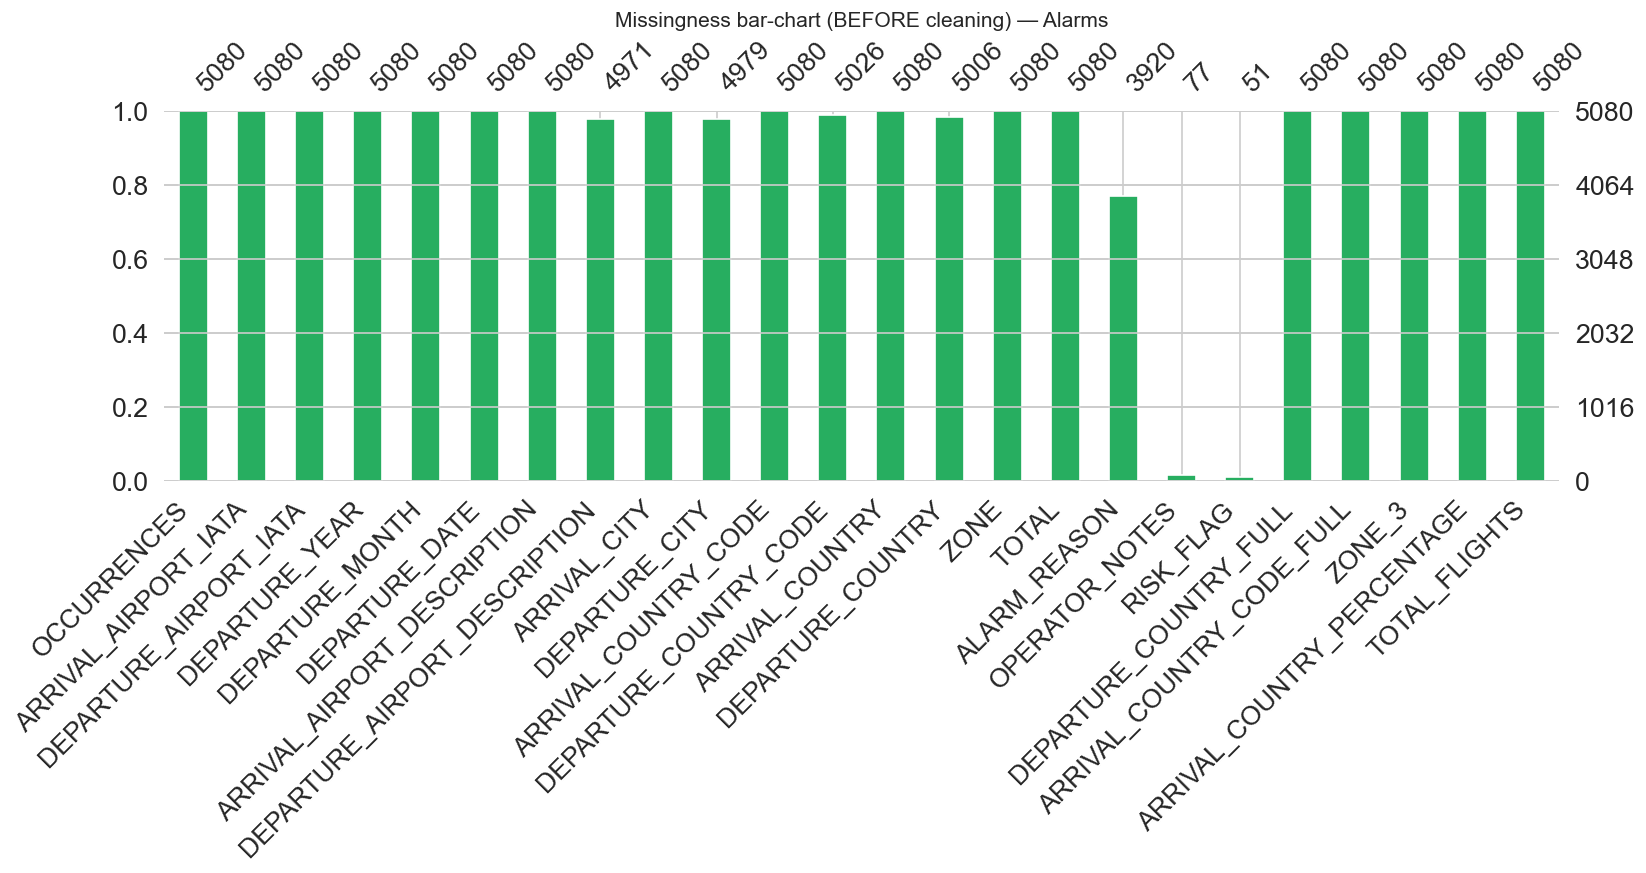

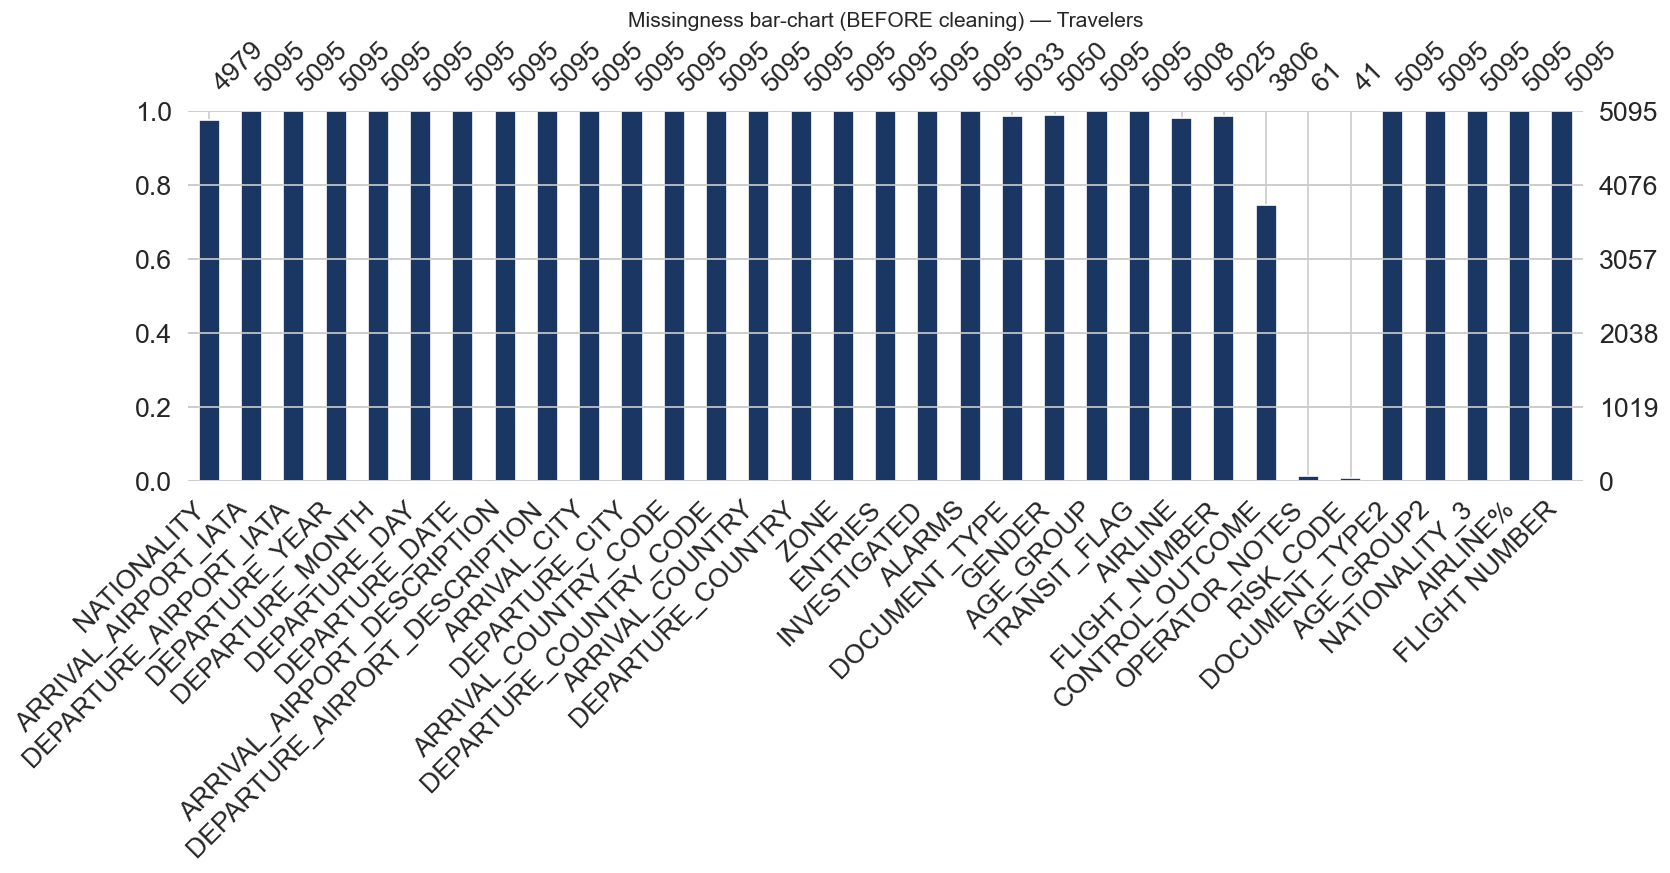

In [400]:
msno.bar(df_alarms, figsize=(15, 4), color=GREEN)
plt.title("Missingness bar-chart (BEFORE cleaning) — Alarms")
plt.show()

msno.bar(df_travelers, figsize=(15, 4), color="#1A3764")
plt.title("Missingness bar-chart (BEFORE cleaning) — Travelers")
plt.show()

raw_missing_alarms    = df_alarms.isnull().sum().copy()
raw_missing_travelers = df_travelers.isnull().sum().copy()
raw_shape_alarms      = df_alarms.shape
raw_shape_travelers   = df_travelers.shape

### 2.2 Categorical-cardinality inspection

We split categorical columns into two buckets: *low-cardinality* (≤ 400 unique values, amenable to visual inspection and rule-based cleanup) and *high-cardinality* (> 400, which will require grouping or encoding). We plot only the first group so the chart stays readable, and print the high-cardinality columns as an early warning. Cardinality > 15 is also flagged in coral as a soft threshold for downstream one-hot encoding.

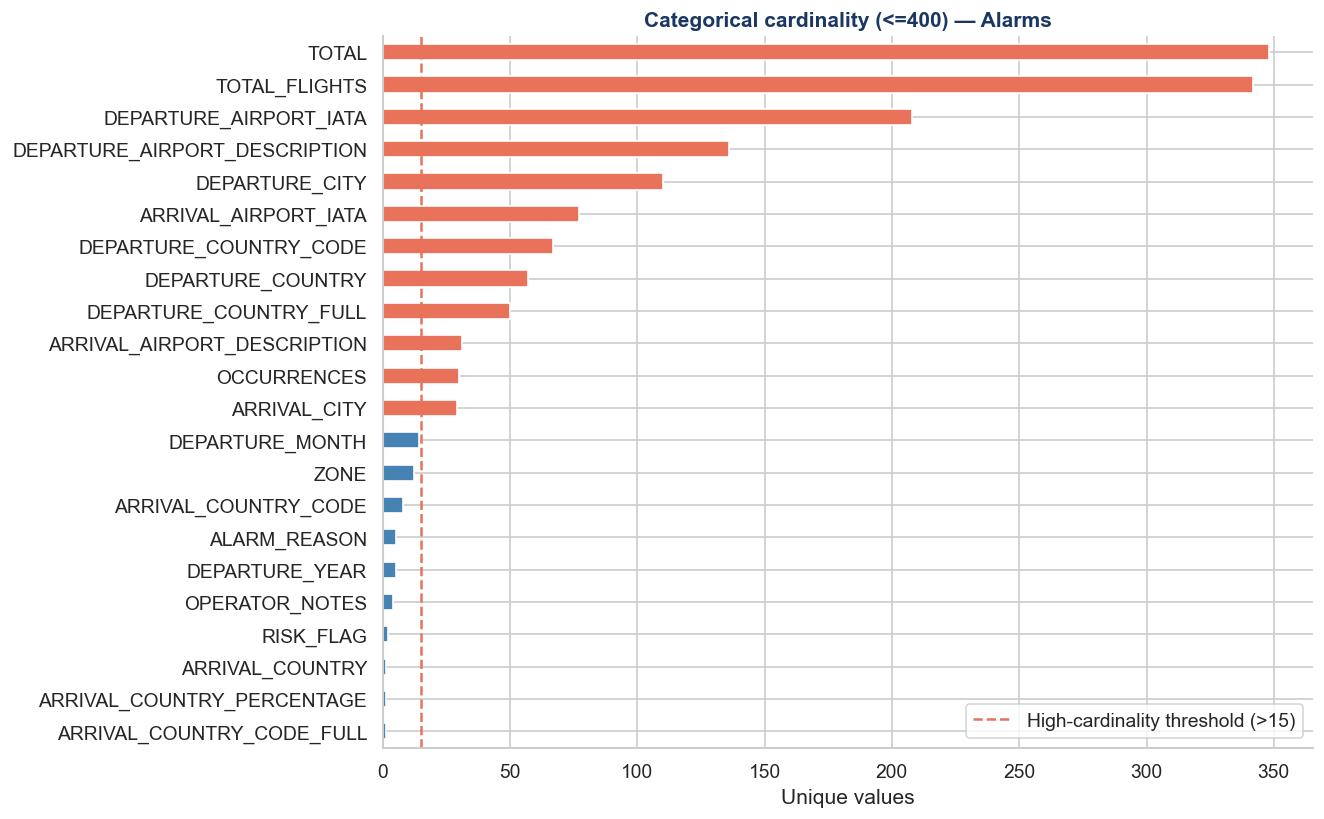

HIGH-CARDINALITY features (excluded from chart):
    'DEPARTURE_DATE': 3810 unique values — needs grouping/target encoding

  Reviewing unique values (Alarms):
  'ARRIVAL_COUNTRY_CODE_FULL' (1 values): ['ITA']

  'ARRIVAL_COUNTRY_PERCENTAGE' (1 values): ['Italia']

  'ARRIVAL_COUNTRY' (1 values): ['Italia']

  'RISK_FLAG' (2 values): ['ALTO', 'MEDIO']

  'OPERATOR_NOTES' (4 values): ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

  'DEPARTURE_YEAR' (5 values): ['2023', '2024', '2024.', '24', 'anno 2024']

  'ALARM_REASON' (5 values): ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

  'ARRIVAL_COUNTRY_CODE' (8 values): ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

  'ZONE' (12 values): ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

  'DEPARTURE_MONTH' (14 values): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', 'FEB', 'GEN']

  'ARRIVAL_CITY' (29 values): ['Ancona', 'Bari', 'Bergamo', 'Bologna', 'Bolzano

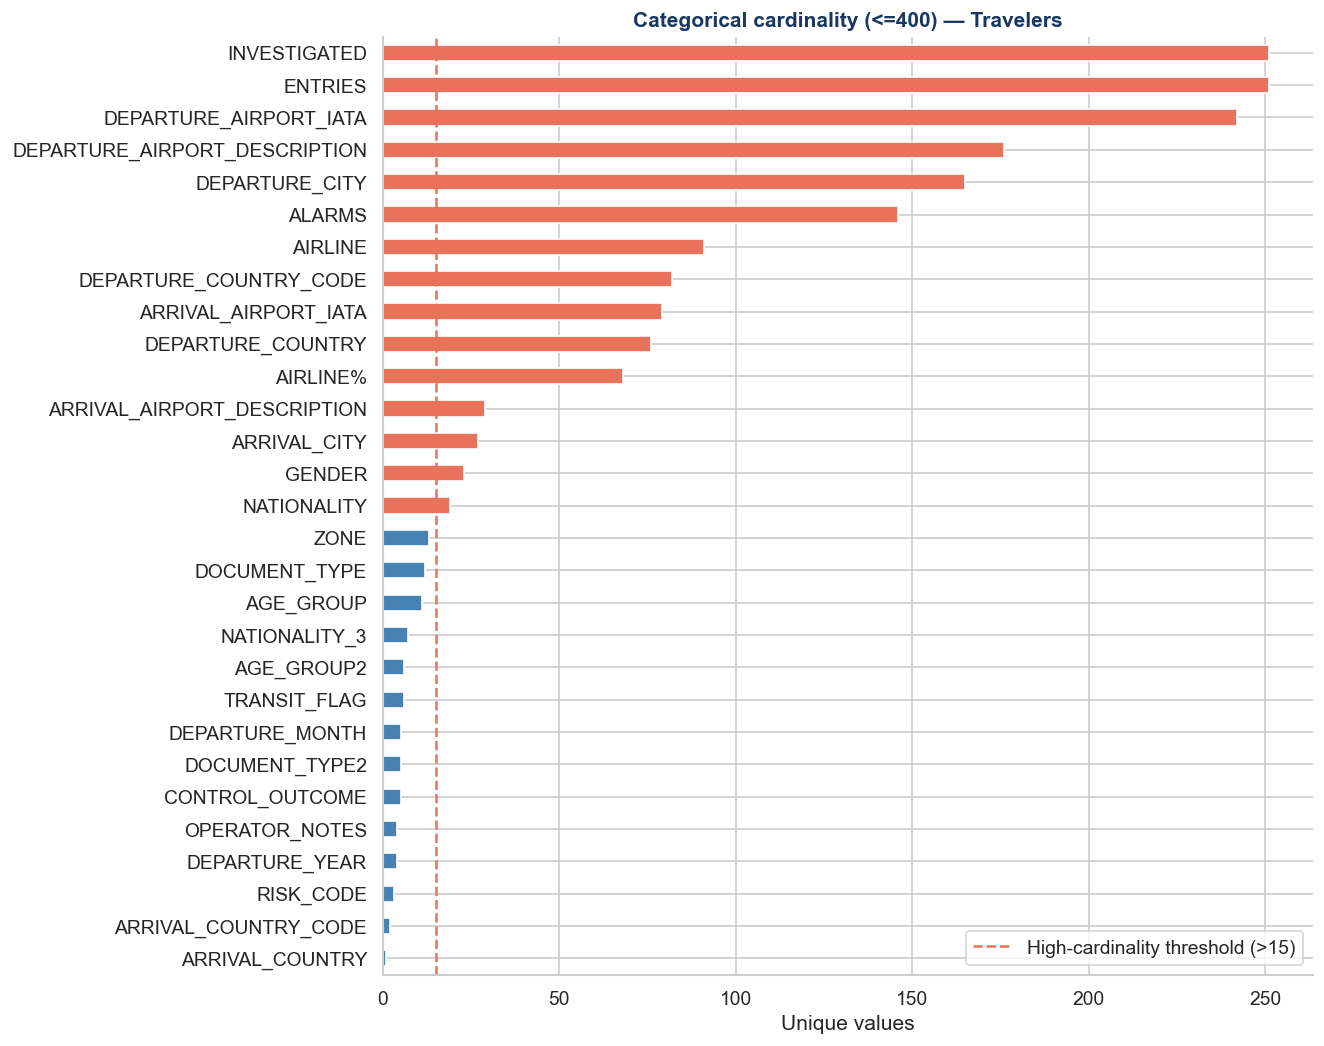

HIGH-CARDINALITY features (excluded from chart):
    'FLIGHT_NUMBER': 701 unique values — needs grouping/target encoding
    'FLIGHT NUMBER': 706 unique values — needs grouping/target encoding
    'DEPARTURE_DATE': 3977 unique values — needs grouping/target encoding

  Reviewing unique values (Travelers):
  'ARRIVAL_COUNTRY' (1 values): ['Italia']

  'ARRIVAL_COUNTRY_CODE' (2 values): ['IT', 'ITA']

  'RISK_CODE' (3 values): ['R1', 'R2', 'R3']

  'DEPARTURE_YEAR' (4 values): ['2023', '2024', '24', 'anno 2024']

  'OPERATOR_NOTES' (4 values): ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

  'CONTROL_OUTCOME' (5 values): ['FERMATO', 'IN ATTESA', 'OK', 'RESPINTO', 'SEGNALATO']

  'DOCUMENT_TYPE2' (5 values): ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

  'DEPARTURE_MONTH' (5 values): ['01', '02', '12', 'FEB', 'GEN']

  'TRANSIT_FLAG' (6 values): ['Multitratta', 'N/C', 'Singola Tratta', 'TRANSITO', 'Tripla Tratta', 'sing

In [401]:
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(df_alarms,    "Alarms")
inspect_categorical(df_travelers, "Travelers")

### 2.3 Travelers cleaning and standardisation

In [402]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "unk", "zz", "none", "xx", "???", " ", "ND", "UNK", "XX", "ZZ", "EU"}

# Departure Colummns analysis
def normalize_departure(df):
    df = df.copy()
    df['DEPARTURE_AIRPORT_IATA'] = (
        df['DEPARTURE_AIRPORT_IATA'].astype(str).str.strip().str.upper().replace({'NAN': np.nan})
    )
    df['DEPARTURE_CITY'] = df['DEPARTURE_AIRPORT_IATA'].map(
        lambda x: iata_mapping[x][0] if x in iata_mapping else np.nan
    )
    df['DEPARTURE_AIRPORT_DESCRIPTION'] = df['DEPARTURE_AIRPORT_IATA'].map(
        lambda x: iata_mapping[x][1] if x in iata_mapping else np.nan
    )
    df['DEPARTURE_COUNTRY'] = df['DEPARTURE_COUNTRY'].astype(str).str.strip()
    df['DEPARTURE_COUNTRY_CODE'] = df['DEPARTURE_COUNTRY'].map(it_to_alpha3)
    return df
df = normalize_departure(df_travelers)
print('Departure columns normalized and enriched with IATA mapping:')
print('country unique         :', df['DEPARTURE_COUNTRY'].nunique())         
print('country code unique    :', df['DEPARTURE_COUNTRY_CODE'].nunique())     
print('iata unique            :', df['DEPARTURE_AIRPORT_IATA'].nunique())
print('airport desc unique    :', df['DEPARTURE_AIRPORT_DESCRIPTION'].nunique())
print('city unique            :', df['DEPARTURE_CITY'].nunique())

miss_iata = (df.loc[df['DEPARTURE_CITY'].isna() & df['DEPARTURE_AIRPORT_IATA'].notna(),'DEPARTURE_AIRPORT_IATA'].unique())
miss_country = (df.loc[df['DEPARTURE_COUNTRY_CODE'].isna() & df['DEPARTURE_COUNTRY'].notna() & (df['DEPARTURE_COUNTRY'] != 'nan'),'DEPARTURE_COUNTRY'].unique())
print('IATA not mapped       :', miss_iata)
print('Country not mapped    :', miss_country)
print('IATA -> city dist.    :', df.groupby('DEPARTURE_AIRPORT_IATA')['DEPARTURE_CITY'].nunique().max())
print('IATA -> airport dist. :', df.groupby('DEPARTURE_AIRPORT_IATA')['DEPARTURE_AIRPORT_DESCRIPTION'].nunique().max())
print('Country -> code dist. :', df.groupby('DEPARTURE_COUNTRY')['DEPARTURE_COUNTRY_CODE'].nunique().max())

# Arrival columns analysis
def normalize_arrival(df):
    df = df.copy()

    df['ARRIVAL_AIRPORT_IATA'] = (
        df['ARRIVAL_AIRPORT_IATA'].astype(str).str.strip().str.upper().replace({'NAN': np.nan})
    )
    df['ARRIVAL_CITY'] = df['ARRIVAL_AIRPORT_IATA'].map(
        lambda x: iata_arrival_mapping[x][0] if x in iata_arrival_mapping else np.nan
    )
    df['ARRIVAL_AIRPORT_DESCRIPTION'] = df['ARRIVAL_AIRPORT_IATA'].map(
        lambda x: iata_arrival_mapping[x][1] if x in iata_arrival_mapping else np.nan
    )
    df['ARRIVAL_COUNTRY']      = 'ITALY'
    df['ARRIVAL_COUNTRY_CODE'] = 'ITA'
    return df
df = normalize_arrival(df_travelers)
print('\nArrival columns normalized and enriched with IATA mapping:')
print('iata unique         :', df['ARRIVAL_AIRPORT_IATA'].nunique())    
print('airport desc unique :', df['ARRIVAL_AIRPORT_DESCRIPTION'].nunique())   
print('city unique         :', df['ARRIVAL_CITY'].nunique())                  

miss_iata = (df.loc[df['ARRIVAL_CITY'].isna() & df['ARRIVAL_AIRPORT_IATA'].notna(), 'ARRIVAL_AIRPORT_IATA'].unique())
print('IATA not mapped     :', miss_iata)
print('IATA -> #city dist. :', df.groupby('ARRIVAL_AIRPORT_IATA')['ARRIVAL_CITY'].nunique().max())
print('IATA -> #airport d. :', df.groupby('ARRIVAL_AIRPORT_IATA')['ARRIVAL_AIRPORT_DESCRIPTION'].nunique().max())

# Fix the Zone column by putting -1 99 and ?? to NaN, and converting to numeric. Then combine with ZONE_3 to fill any remaining missing values, before dropping ZONE_3.
if "ZONE" in df_travelers.columns:
    df_travelers["ZONE"] = df_travelers["ZONE"].replace(["-1", "99", "??"], np.nan)
    df_travelers["ZONE"] = pd.to_numeric(df_travelers["ZONE"], errors="coerce")
    df_travelers.loc[(df_travelers["ZONE"] < 0) | (df_travelers["ZONE"] > 10), "ZONE"] = np.nan
    df_travelers["ZONE"] = df_travelers["ZONE"].astype("Int64")
    df_travelers.drop(columns=["ZONE_3"], inplace=True, errors="ignore")
if "ZONE" in df_travelers.columns:
    print(f"\nZONE distribution after cleaning:")
    print(df_travelers["ZONE"].value_counts(dropna=False).to_string())

# Gender analysis: remapping values
if "GENDER" in df_travelers.columns:
    gender_map = {
    "MASCHIO": "M", "MALE": "M", "1": "M", # Man
    "FEMMINA": "F", "FEMALE": "F", "2": "F",  # female
    " ": "N.D.", "-": "N.D.", "//": "N.D.", "X": "N.D.", "N/B": "N.D.", "ND": "N.D.", "UNKNOWN": "N.D.", "UNKN": "N.D.", "?": "N.D."  # Not Declared / Unknown
}
    df_travelers["GENDER"] = df_travelers["GENDER"].str.upper().replace(gender_map).fillna("N.D.")
    print(f"\nGENDER distribution after remapping:")
    print(df_travelers["GENDER"].value_counts(dropna=False).to_string())

# We Standardize Operator Notes, uppercasing and stripping whitespace, then fillna with placeholder and print unique values to check for consistency.
if "OPERATOR_NOTES" in df_travelers.columns:
    df_travelers["OPERATOR_NOTES"] = df_travelers["OPERATOR_NOTES"].str.upper().str.strip()
    df_travelers["OPERATOR_NOTES"] = df_travelers["OPERATOR_NOTES"].replace(np.nan, "NO_NOTES")
    print(f"\nOPERATOR_NOTES unique values after cleaning:")
    print(df_travelers["OPERATOR_NOTES"].value_counts(dropna=False).to_string())

# Transit Flag analysis: we replace null values with "Unknown" and print the distribution to check for consistency.
if "TRANSIT_FLAG" in df_travelers.columns:
    transit_map = {"SINGOLA TRATTA": "1", "MULTITRATTA": "2", "TRIPLA TRATTA": "3", "TRANSITO": "STOPOVER"}
    df_travelers["TRANSIT_FLAG"] = df_travelers["TRANSIT_FLAG"].str.upper().replace(transit_map).replace("N/C", np.nan)
    print(f"\nTRANSIT_FLAG distribution after filling nulls with 'Unknown': {df_travelers['TRANSIT_FLAG'].value_counts(dropna=False).to_string()}")

# Risk code analysis
if "RISK_CODE" in df_travelers.columns:
    print(f"\nRISK_CODE distribution: {df_travelers['RISK_CODE'].value_counts(dropna=False).to_string()}")

# Control outcome analysis
if "CONTROL_OUTCOME" in df_travelers.columns:
    print(f"\nCONTROL_OUTCOME distribution: {df_travelers['CONTROL_OUTCOME'].value_counts(dropna=False).to_string()}")

# replace null values in nationality with "Unknown"
if "NATIONALITY" in df_travelers.columns:
    df_travelers["NATIONALITY"] = df_travelers["NATIONALITY"].fillna("Unknown")
    df_travelers["NATIONALITY"] = df_travelers["NATIONALITY"].replace(PLACEHOLDER_NULL, "Unknown")
    print(f"\nNATIONALITY distribution after filling nulls with 'Unknown':")
    print(df_travelers["NATIONALITY"].value_counts(dropna=False).to_string())
# if the values differnet from "Unknown" are the same in nationality and nationality_3, we can can drop nationality_3
if "NATIONALITY" in df_travelers.columns and "NATIONALITY_3" in df_travelers.columns:
    if set(df_travelers.loc[df_travelers["NATIONALITY"] != "Unknown", "NATIONALITY"].unique()) == set(df_travelers.loc[df_travelers["NATIONALITY"] != "Unknown", "NATIONALITY_3"].unique()):
        df_travelers.drop(columns=["NATIONALITY_3"], inplace=True, errors="ignore")
        print("\nDropped 'NATIONALITY_3' since it is redundant with 'NATIONALITY' after filling nulls.")

# We drop Departure Year and Month since they are redundant with Departure Date, which is more complete and can be used to extract the year and month if needed.
if "DEPARTURE_DATE" in df_travelers.columns:
    df_travelers.drop(columns=["DEPARTURE_YEAR", "DEPARTURE_MONTH"], inplace=True, errors="ignore")
    print("\nDropped 'DEPARTURE_YEAR' and 'DEPARTURE_MONTH' since they are redundant with 'DEPARTURE_DATE'.")

# Age_group and Age_group2 analysis: Since they are related and Age_group2 has a normal distribution without outliers, we can drop Age_group and keep Age_group2 as the main age feature.
if "AGE_GROUP" in df_travelers.columns and "AGE_GROUP2" in df_travelers.columns:
    df_travelers.drop(columns=["AGE_GROUP"], inplace=True, errors="ignore")
    print("\nDropped 'AGE_GROUP' since 'AGE_GROUP2' has a more consistent distribution without outliers.")

# Document type and Document type 2 analysis: since they are related and Document type 2 has a more consistent distribution without outliers, we can drop Document type and keep Document type 2 as the main document type feature.
if "DOCUMENT_TYPE" in df_travelers.columns and "DOCUMENT_TYPE2" in df_travelers.columns:
    df_travelers.drop(columns=["DOCUMENT_TYPE"], inplace=True, errors="ignore")
    print("\nDropped 'DOCUMENT_TYPE' since 'DOCUMENT_TYPE2' has a more consistent distribution without outliers.")

# Airline and Airline% analysis: since they are related and Airline% has a more consistent distribution without outliers, we can drop Airline and keep Airline as the main airline feature.
if "AIRLINE" in df_travelers.columns and "AIRLINE%" in df_travelers.columns:
    df_travelers.drop(columns=["AIRLINE"], inplace=True, errors="ignore")
    print("\nDropped 'AIRLINE' since 'AIRLINE%' has a more consistent distribution without outliers.")

# Flight number and Flight number analysis: # remove the - in the values and spaces in the values, then print the unique values to check for consistency.
# Since they are related and Flight number has a more consistent distribution without outliers, we can drop Flight_number and keep Flight number as the main flight number feature.
if "FLIGHT_NUMBER" in df_travelers.columns and "FLIGHT NUMBER" in df_travelers.columns:
    df_travelers["FLIGHT_NUMBER"] = df_travelers["FLIGHT_NUMBER"].str.replace("-", "").str.replace(" ", "").str.upper()
    df_travelers["FLIGHT NUMBER"] = df_travelers["FLIGHT NUMBER"].str.replace("-", "").str.replace(" ", "").str.upper()
    df_travelers.drop(columns=["FLIGHT_NUMBER"], inplace=True, errors="ignore")
    print("\nDropped 'FLIGHT_NUMBER' since 'FLIGHT NUMBER' has a more consistent distribution without outliers.")

# Finally, we clean the signal columns (Entries, Investigated, Alarms) by removing non-numeric characters, converting to numeric, and filtering out invalid values (negative or >200). 
# We then print the top 5 largest values in each column to check for consistency.
signal_cols = ['ENTRIES', 'INVESTIGATED', 'ALARMS']
before = len(df_travelers)
for col in signal_cols:
    df_travelers[col] = (df_travelers[col].astype(str)
                        .str.replace(r'(?i)pax', '', regex=True)
                        .str.replace(r'\s+', '', regex=True)
    )
    df_travelers[col] = pd.to_numeric(df_travelers[col], errors='coerce')
mask = (
    df_travelers['ENTRIES'].between(0, 200) &
    df_travelers['INVESTIGATED'].between(0, 200) &
    df_travelers['ALARMS'].between(0, 200)
)
df_travelers = df_travelers[mask].copy()
print(f"\nDropped {before - len(df_travelers)} rows (negative, >200, or non-numeric) in ENTRIES, INVESTIGATED, or ALARMS columns.")

for col in signal_cols:
    df_travelers[col] = df_travelers[col].astype(int)
    print(f"\nTop 5 values in '{col}':")
    print(df_travelers[col].nlargest(5).to_string())

# Save cleaned datasets
df_travelers.to_csv("io/TRAVELERS_CLEANED.csv", index=False)
print(f"\nCleaned travelers dataset {df_travelers.shape[0]} rows x {df_travelers.shape[1]} columns saved to 'io/TRAVELERS_CLEANED.csv'.")

Departure columns normalized and enriched with IATA mapping:
country unique         : 76
country code unique    : 76
iata unique            : 177
airport desc unique    : 176
city unique            : 165
IATA not mapped       : []
Country not mapped    : []
IATA -> city dist.    : 1
IATA -> airport dist. : 1
Country -> code dist. : 1

Arrival columns normalized and enriched with IATA mapping:
iata unique         : 29
airport desc unique : 29
city unique         : 27
IATA not mapped     : []
IATA -> #city dist. : 1
IATA -> #airport d. : 1

ZONE distribution after cleaning:
ZONE
2       1774
5       1106
8        878
4        564
1        252
9        220
7        184
6        107
<NA>       5
0          4
10         1

GENDER distribution after remapping:
GENDER
F       2248
M       2210
N.D.     637

OPERATOR_NOTES unique values after cleaning:
OPERATOR_NOTES
NO_NOTES                5034
VERIFICA RICHIESTA        18
ALERT MANUALE             16
SEGNALAZIONE ESTERNA      16
PASSEGGERO N

### 2.4 ALARMS cleaning and standardisation

In [403]:
# Dropping columns from alarms that are redundant with travelers or have too many missing values, and printing the distribution of the remaining columns to check for consistency.
df_alarms.drop(columns=["DEPARTURE_MONTH", "DEPARTURE_YEAR", "ARRIVAL_COUNTRY_CODE", "ARRIVAL_COUNTRY_CODE_PERCENTAGE"], inplace=True, errors="ignore")

# Cleaning function
PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'none'}
def clean_placeholders(s):
    s = s.astype(str).str.strip()
    return s.where(~s.str.lower().isin(PLACEHOLDER_NULL), np.nan)

# Occurces map: we lowercase, strip, and map to the standardized categories, then print the distribution to check for consistency.
df_alarms['OCCURRENCES'] = df_alarms['OCCURRENCES'].str.lower().str.strip().map(occurrences_map)
print("OCCURRENCES distribution:")
print(df_alarms["OCCURRENCES"].value_counts(dropna=False).to_string())

# Zone column analysis: we replace -1, 99, and ?? with NaN, convert to numeric, and filter out invalid values (negative or >10). 
# We then combine with ZONE_3 to fill any remaining missing values, before dropping ZONE_3. Finally, we print the distribution to check for consistency.
if "ZONE" in df_alarms.columns:
    df_alarms["ZONE"] = pd.to_numeric(
        df_alarms["ZONE"].replace(["-1", "99", "??"], np.nan), errors="coerce"
    )
    df_alarms.loc[(df_alarms["ZONE"] < 0) | (df_alarms["ZONE"] > 10), "ZONE"] = np.nan
    df_alarms["ZONE"] = (df_alarms["ZONE"].astype("Int64").combine_first(df_alarms["ZONE_3"]))
    df_alarms.drop(columns=["ZONE_3"], inplace=True, errors="ignore")
    print(f"\nZONE distribution after cleaning:\n{df_alarms['ZONE'].value_counts(dropna=False).to_string()}")

# ALARM_REASON / OPERATOR_NOTES: uppercase + placeholder fill
text_fill = {"ALARM_REASON": "NO REASON PROVIDED", "OPERATOR_NOTES": "NO MANUAL NOTES"}
for col, placeholder in text_fill.items():
    if col in df_alarms.columns:
        df_alarms[col] = (df_alarms[col].astype(str).str.strip().str.upper()
                                        .replace({'NAN': np.nan})
                                        .fillna(placeholder))

# RISK_FLAG: translate IT->EN, fill NaN with LOW RISK
if "RISK_FLAG" in df_alarms.columns:
    df_alarms["RISK_FLAG"] = (df_alarms["RISK_FLAG"]
                              .replace({"ALTO": "HIGH RISK", "MEDIO": "MEDIUM RISK"})
                              .fillna("LOW RISK"))
    print(f"\nRISK_FLAG distribution:\n{df_alarms['RISK_FLAG'].value_counts(dropna=False).to_string()}")

# DEPARTURE: IATA -> city + airport, country -> alpha-3 
iata_to_city    = {k: v[0] for k, v in iata_mapping.items()}
iata_to_airport = {k: v[1] for k, v in iata_mapping.items()}

iata_dep = df_alarms['DEPARTURE_AIRPORT_IATA'].astype(str).str.upper().str.strip()
df_alarms['DEPARTURE_AIRPORT_IATA']        = iata_dep
df_alarms['DEPARTURE_CITY']                = iata_dep.map(iata_to_city)
df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'] = iata_dep.map(iata_to_airport)

# Combine the 2 country columns: prefer DEPARTURE_COUNTRY_FULL (already standardised),
# fallback on DEPARTURE_COUNTRY for missing values
country = (clean_placeholders(df_alarms['DEPARTURE_COUNTRY_FULL'])
           .combine_first(clean_placeholders(df_alarms['DEPARTURE_COUNTRY'])))
df_alarms['DEPARTURE_COUNTRY']      = country
df_alarms['DEPARTURE_COUNTRY_CODE'] = country.map(it_to_alpha3)
df_alarms.drop(columns=['DEPARTURE_COUNTRY_FULL'], inplace=True, errors='ignore')

print('\n--- DEPARTURE ---')
print(f"  IATA unique         : {df_alarms['DEPARTURE_AIRPORT_IATA'].nunique()}")
print(f"  airport desc unique : {df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].nunique()}")
print(f"  city unique         : {df_alarms['DEPARTURE_CITY'].nunique()}")
print(f"  country unique      : {df_alarms['DEPARTURE_COUNTRY'].nunique()}")
print(f"  country code unique : {df_alarms['DEPARTURE_COUNTRY_CODE'].nunique()}")
print(f"  city -> airport null : {df_alarms['DEPARTURE_CITY'].isna().sum()} -> "
      f"{df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].isna().sum()}")
print(f"  country code null   : {df_alarms['DEPARTURE_COUNTRY_CODE'].isna().sum()}")

# ARRIVAL: IATA -> city + airport, country = Italy
iata_arr = df_alarms['ARRIVAL_AIRPORT_IATA'].astype(str).str.upper().str.strip()
df_alarms['ARRIVAL_AIRPORT_IATA']        = iata_arr
df_alarms['ARRIVAL_CITY']                = iata_arr.map(iata_to_city)
df_alarms['ARRIVAL_AIRPORT_DESCRIPTION'] = iata_arr.map(iata_to_airport)
df_alarms['ARRIVAL_COUNTRY']             = 'Italia'
df_alarms['ARRIVAL_COUNTRY_CODE']        = 'ITA'

print('\n--- ARRIVAL ---')
print(f"  IATA unique         : {df_alarms['ARRIVAL_AIRPORT_IATA'].nunique()}")
print(f"  airport desc unique : {df_alarms['ARRIVAL_AIRPORT_DESCRIPTION'].nunique()}")
print(f"  city unique         : {df_alarms['ARRIVAL_CITY'].nunique()}")
print(f"  city -> airport null : {df_alarms['ARRIVAL_CITY'].isna().sum()} -> "
      f"{df_alarms['ARRIVAL_AIRPORT_DESCRIPTION'].isna().sum()}")

# TOTAL_FLIGHTS: keep clean column, drop noisy TOTAL
def clean_count(series, max_valid=1000):
    s = (series.astype(str).str.strip()
                .str.replace(r'\s*voli\s*$', '', regex=True)
                .str.lstrip('~'))
    s = pd.to_numeric(s, errors='coerce')
    return s.where((s >= 0) & (s <= max_valid)).fillna(0).round().astype(int)

df_alarms['TOTAL_FLIGHTS'] = clean_count(df_alarms['TOTAL_FLIGHTS'])
df_alarms.drop(columns=['TOTAL'], inplace=True, errors='ignore')
print(f"\nTOTAL_FLIGHTS:\n{df_alarms['TOTAL_FLIGHTS'].describe().to_string()}")

# Save cleaned dataset
df_alarms.to_csv("io/ALARMS_CLEANED.csv", index=False)
print(f"\nCleaned alarms dataset {df_alarms.shape[0]} rows x {df_alarms.shape[1]} cols saved to 'io/ALARMS_CLEANED.csv'.")

OCCURRENCES distribution:
OCCURRENCES
entries                            626
available_inbound_flights          588
viewed_not_investigated_flights    572
generated_alerts                   547
investigated_flights               543
investigated_entries               528
flights_with_alerts                507
entries_with_alerts                468
negative_outcome                   296
closed_alerts                      259
relevant_alerts                    112
other                               16
missing_update                       8
open_alerts                          7
NaN                                  3

ZONE distribution after cleaning:
ZONE
2     1841
5     1474
8      580
4      568
6      213
1      180
7      144
9       79
10       1

RISK_FLAG distribution:
RISK_FLAG
LOW RISK       5029
HIGH RISK        27
MEDIUM RISK      24

--- DEPARTURE ---
  IATA unique         : 112
  airport desc unique : 111
  city unique         : 103
  country unique      : 50
  country cod

### 2.5 Date parsing & temporal alignment

The two datasets use *different* date conventions, and the Alarms file in particular mixes at least six formats (`dd/mm/yyyy HH:MM:SS`, `yyyy/mm/dd`, `dd.mm.yyyy`, `MMM dd yyyy` with Italian month abbreviations, `dd-mm-yy`, …). We:

1. print the format distribution *before* cleaning by replacing digits with `N` and letters with `A` (a "pattern fingerprint" technique);
2. rewrite each known pattern to ISO 8601 via regex;
3. parse with `pd.to_datetime(..., errors='coerce')`;
4. print the fingerprint distribution *after* cleaning to verify every row now conforms.

In [404]:
def extract_pattern(val):
    s = re.sub(r"\d", "N", str(val))
    return re.sub(r"[a-zA-Z]", "A", s)

def parse_dates(s, name=""):
    raw = (s.astype(str).str.strip()
            .str.replace(r"(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})",
                         r"\1 \2", regex=True))
    out = pd.to_datetime(raw, format='mixed', dayfirst=True, errors='coerce')
    out = out.fillna(pd.to_datetime(raw, errors='coerce'))
    print(f"  {name}: parse failures (will be dropped) = {out.isna().sum()}")
    return out

# Inspect formats BEFORE
print("Date-format patterns BEFORE cleaning:")
for name, df in [("Alarms", df_alarms), ("Travelers", df_travelers)]:
    counts = df["DEPARTURE_DATE"].dropna().astype(str).map(extract_pattern).value_counts()
    print(f"  {name}:\n    " + counts.to_string().replace("\n", "\n    "))

# Parse
print("\nParsing:")
df_alarms["DEPARTURE_DATE"]    = parse_dates(df_alarms["DEPARTURE_DATE"],    "Alarms")
df_travelers["DEPARTURE_DATE"] = parse_dates(df_travelers["DEPARTURE_DATE"], "Travelers")

# Drop rows that couldn't be parsed
before = len(df_alarms), len(df_travelers)
df_alarms    = df_alarms.dropna(subset=["DEPARTURE_DATE"]).reset_index(drop=True)
df_travelers = df_travelers.dropna(subset=["DEPARTURE_DATE"]).reset_index(drop=True)
print(f"\nRows dropped: Alarms {before[0]-len(df_alarms)} | Travelers {before[1]-len(df_travelers)}")

# Inspect formats AFTER
print("\nDate-format patterns AFTER cleaning:")
for name, df in [("Alarms", df_alarms), ("Travelers", df_travelers)]:
    counts = df["DEPARTURE_DATE"].dropna().astype(str).map(extract_pattern).value_counts()
    print(f"  {name}:\n    " + counts.to_string().replace("\n", "\n    "))

Date-format patterns BEFORE cleaning:
  Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4675
    AAAA/AA/AA               76
    AA-AA-AA                 76
    AAA AA AAAA              68
    AA.AA.AAAA               62
    AAAA-AA-AAAAA:AA:AA      62
    AA/AA/AAAA AA:AA:AA      61
  Travelers:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4485
    AAA AA AAAA              78
    AAAA-AA-AAAAA:AA:AA      65
    AA-AA-AA                 65
    AAAA/AA/AA               65
    AA/AA/AAAA AA:AA:AA      65
    AA.AA.AAAA               54

Parsing:
  Alarms: parse failures (will be dropped) = 32
  Travelers: parse failures (will be dropped) = 37

Rows dropped: Alarms 32 | Travelers 37

Date-format patterns AFTER cleaning:
  Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    5048
  Travelers:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4840


### 2.6 Post-cleaning missing-value audit

A side-by-side table compares *per column* the number of missing values before and after section 2.3 – section 2.7. We only show rows where the count actually changed — the rest is untouched. The follow-up `missingno` bar-charts in green confirm visually that the key fields are now dense.


ALARMS  (shape: (5080, 24) -> (5048, 19))


,Missing BEFORE,Missing AFTER
Column,,
ALARM_REASON,1160,0
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0
ARRIVAL_COUNTRY_CODE,0,0
ARRIVAL_COUNTRY_CODE_FULL,0,0
ARRIVAL_COUNTRY_PERCENTAGE,0,0
DEPARTURE_AIRPORT_DESCRIPTION,109,0



TRAVELERS  (shape: (5095, 33) -> (4840, 26))


,Missing BEFORE,Missing AFTER
Column,,
AGE_GROUP,0,dropped
AGE_GROUP2,0,0
AIRLINE,87,dropped
AIRLINE%,0,0
ALARMS,0,0
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0


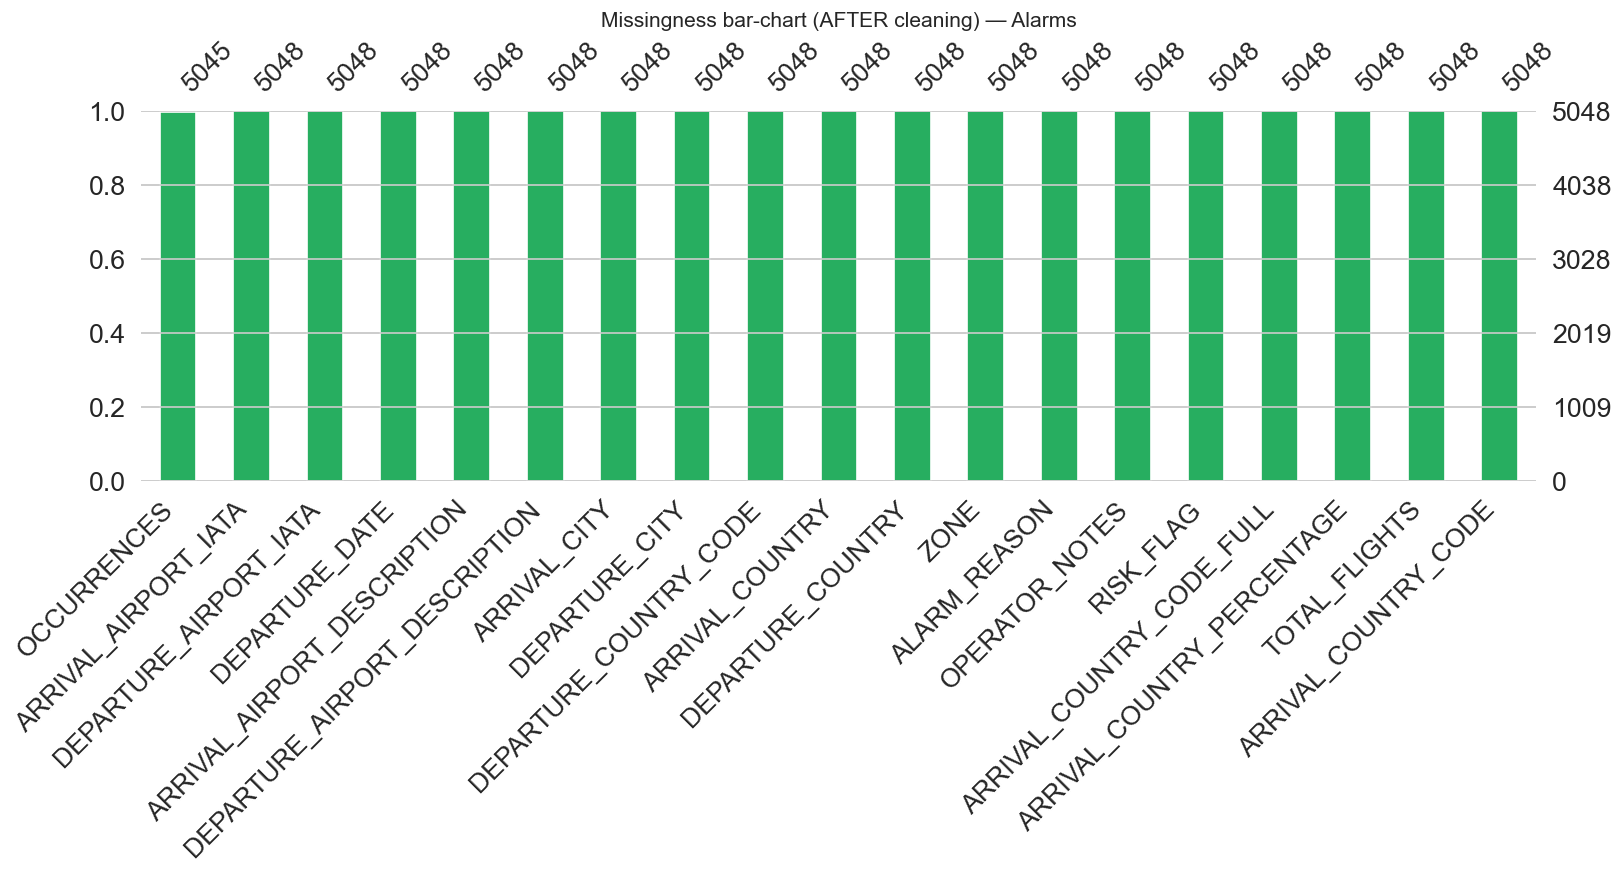

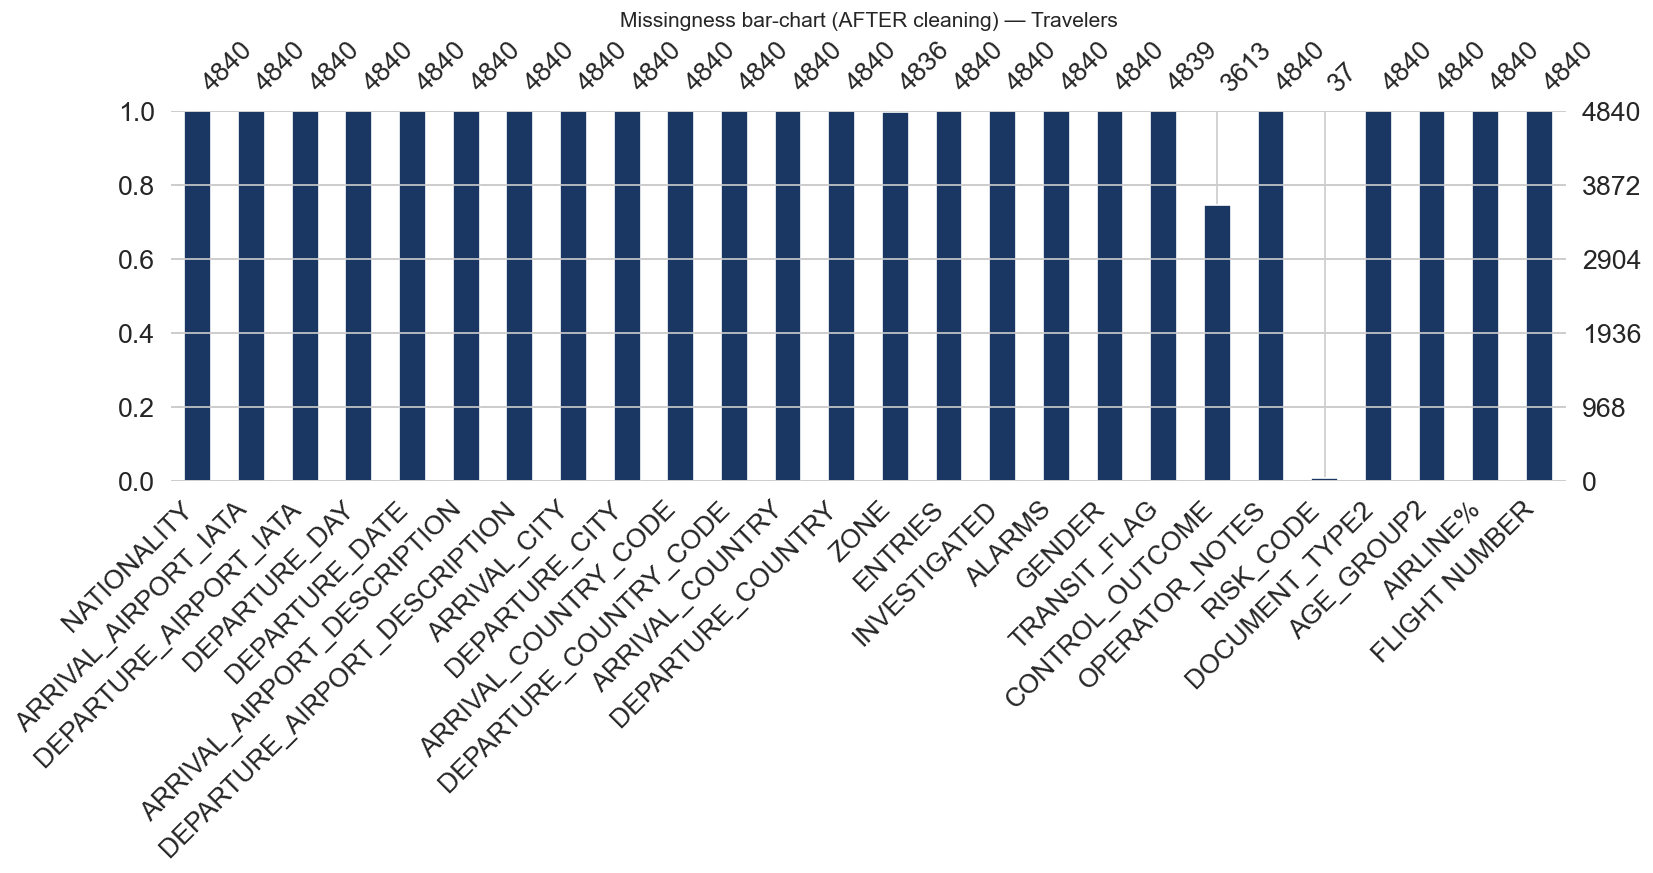

In [405]:
def missing_comparison(df_now, raw_missing, dataset_name, raw_shape):
    """Compare per-column missing-value counts before and after the cleaning pipeline."""
    now = df_now.isnull().sum()
    col_map = {c.upper(): c for c in df_now.columns}
    raw_missing = raw_missing.copy()
    raw_missing.index = [col_map.get(c.upper(), c) for c in raw_missing.index]
    all_cols = sorted(set(raw_missing.index) | set(now.index))
    rows = [{"Column": c,
             "Missing BEFORE": raw_missing.get(c, "—"),
             "Missing AFTER":  now.get(c, "dropped")} for c in all_cols]
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n{dataset_name}  (shape: {raw_shape} -> {df_now.shape})")
    display(report)

missing_comparison(df_alarms,    raw_missing_alarms,    "ALARMS",    raw_shape_alarms)
missing_comparison(df_travelers, raw_missing_travelers, "TRAVELERS", raw_shape_travelers)

msno.bar(df_alarms, figsize=(15, 4), color=GREEN)
plt.title("Missingness bar-chart (AFTER cleaning) — Alarms")
plt.show()

msno.bar(df_travelers, figsize=(15, 4), color="#1A3764")
plt.title("Missingness bar-chart (AFTER cleaning) — Travelers")
plt.show()

### 2.7 Final schema verification

We print the final shape, column list, and dtype counts for both datasets — the schema contract on which the feature-engineering block will depend. The cleaned DataFrames remain in memory (`df_alarms`, `df_travelers`); no disk persistence is required since the notebook runs end-to-end in a single session.


In [406]:
print(f"ALARMS -> {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} cols")
# order columns for better readability
cols_order = ['DEPARTURE_DATE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 
              'ARRIVAL_AIRPORT_IATA', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ZONE',
               'OCCURRENCES', 'ALARM_REASON', 'OPERATOR_NOTES', 'RISK_FLAG', 'TOTAL_FLIGHTS']
df_alarms = df_alarms[cols_order + [col for col in df_alarms.columns if col not in cols_order]]
df_alarms.sample(5)

ALARMS -> 5,048 rows x 19 cols


,DEPARTURE_DATE,DEPARTURE_AIRPORT_IATA,DEPARTURE_CITY,DEPARTURE_AIRPORT_DESCRIPTION,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_AIRPORT_IATA,ARRIVAL_CITY,ARRIVAL_AIRPORT_DESCRIPTION,ARRIVAL_COUNTRY,ARRIVAL_COUNTRY_CODE,ZONE,OCCURRENCES,ALARM_REASON,OPERATOR_NOTES,RISK_FLAG,TOTAL_FLIGHTS,ARRIVAL_COUNTRY_CODE_FULL,ARRIVAL_COUNTRY_PERCENTAGE
4926,2024-01-10 17:55:00,CAI,Cairo,Cairo International,Egitto,EGY,FCO,Roma,Fiumicino,Italia,ITA,5,available_inbound_flights,INTERPOL,NO MANUAL NOTES,LOW RISK,1,ITA,Italia
2258,2024-01-07 17:50:00,JFK,New York,John F. Kennedy International,Stati Uniti,USA,FCO,Roma,Fiumicino,Italia,ITA,5,viewed_not_investigated_flights,NSIS,NO MANUAL NOTES,LOW RISK,1,ITA,Italia
2623,2024-01-08 19:45:00,LGW,London,London Gatwick,Regno Unito,GBR,MXP,Milano,Malpensa,Italia,ITA,2,available_inbound_flights,MANUALE,NO MANUAL NOTES,LOW RISK,1,ITA,Italia
246,2024-01-14 11:30:00,SAW,Istanbul,Sabiha Gokcen,Turchia,TUR,BLQ,Bologna,Guglielmo Marconi,Italia,ITA,8,investigated_entries,MANUALE,NO MANUAL NOTES,LOW RISK,161,ITA,Italia
4151,2024-01-20 01:35:00,PEK,Beijing,Beijing Capital International,Cina,CHN,MXP,Milano,Malpensa,Italia,ITA,2,closed_alerts,SDI,NO MANUAL NOTES,LOW RISK,12,ITA,Italia


In [407]:
print(f"TRAVELERS -> {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} cols")
# order columns for better readability
cols_order = ['DEPARTURE_DATE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 
              'ARRIVAL_AIRPORT_IATA', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ZONE', 
              'GENDER', 'NATIONALITY', 'TRANSIT_FLAG', 'RISK_CODE', 'CONTROL_OUTCOME', 'AGE_GROUP2', 'DOCUMENT_TYPE2', 'AIRLINE%', 'FLIGHT NUMBER', 'OPERATOR_NOTES', 'ENTRIES', 'INVESTIGATED', 'ALARMS']
df_travelers = df_travelers[cols_order + [col for col in df_travelers.columns if col not in cols_order]]
df_travelers.sample(5)

TRAVELERS -> 4,840 rows x 26 cols


,DEPARTURE_DATE,DEPARTURE_AIRPORT_IATA,DEPARTURE_CITY,DEPARTURE_AIRPORT_DESCRIPTION,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_AIRPORT_IATA,ARRIVAL_CITY,ARRIVAL_AIRPORT_DESCRIPTION,ARRIVAL_COUNTRY,ARRIVAL_COUNTRY_CODE,ZONE,GENDER,NATIONALITY,TRANSIT_FLAG,RISK_CODE,CONTROL_OUTCOME,AGE_GROUP2,DOCUMENT_TYPE2,AIRLINE%,FLIGHT NUMBER,OPERATOR_NOTES,ENTRIES,INVESTIGATED,ALARMS,DEPARTURE_DAY
519,2024-01-16 11:35:00,MAN,Manchester,Manchester,Regno Unito,GBR,BGY,Bergamo,Orio al Serio,Italia,ITA,2,M,ALB,1,NaN,NaN,31-45,N.D.,Ryanair DAC,FR3216,NO_NOTES,1,1,0,16
1800,2024-02-26 12:35:00,PKX,Pechino,Beijing Daxing International Airport,Cina,CHN,FCO,Roma,Fiumicino,Italia,IT,5,M,ALB,1,NaN,IN ATTESA,46-60,Visto,China Eastern Airlines,MU0787,NO_NOTES,1,1,0,26
3592,2024-02-02 16:55:00,TIA,Tirana,Rinas Mother Teresa,Albania,ALB,BRI,Bari,Palese,Italia,ITA,9,M,ALB,1,NaN,IN ATTESA,18-30,Passaporto,Wizz Air Malta,W46647,NO_NOTES,60,60,5,2
1239,2024-02-21 20:35:00,TIA,Tirana,Rinas Mother Teresa,Albania,ALB,BGY,Bergamo,Orio al Serio,Italia,ITA,2,M,ALB,1,NaN,IN ATTESA,0-17,N.D.,Ryanair DAC,FR8356,NO_NOTES,50,50,9,21
4136,2024-01-23 06:45:00,STN,Londra,Stansted,Regno Unito,GBR,MXP,Milano,Malpensa,Italia,ITA,2,M,ALB,1,NaN,NaN,61+,Passaporto,Ryanair DAC,FR2757,NO_NOTES,1,1,3,23


### 2.8 Merging and consistency checks

The two datasets share only a subset of columns, which we use as "keys" to check for consistency and to merge the datasets in a single DataFrame (`df_master`) that will be used for the downstream analysis. We check that the key columns have the same number of unique values and similar missingness patterns, and we print the shape and column list of the merged DataFrame to verify that the merge went as expected.


In [413]:
merge_keys = [
    "ARRIVAL_AIRPORT_IATA",
    "DEPARTURE_AIRPORT_IATA",
    "DEPARTURE_DATE",
    "DEPARTURE_COUNTRY_CODE",
    "ARRIVAL_COUNTRY_CODE"
]
print("Missing dates in alarms:", df_alarms["DEPARTURE_DATE"].isna().sum())
print("Missing dates in travelers:", df_travelers["DEPARTURE_DATE"].isna().sum())

print("Duplicated flight keys in alarms:", df_alarms.duplicated(merge_keys).sum())
print("Duplicated flight keys in travelers:", df_travelers.duplicated(merge_keys).sum())

print("Unique flight keys in alarms:", df_alarms[merge_keys].drop_duplicates().shape[0])
print("Unique flight keys in travelers:", df_travelers[merge_keys].drop_duplicates().shape[0])

travelers_flight = (
    df_travelers
    .groupby(merge_keys, dropna=False)
    .agg(
        entries=("ENTRIES", "sum"),
        investigated=("INVESTIGATED", "sum"),
        alarms=("ALARMS", "sum"),
        n_traveler_rows=("NATIONALITY", "size"),
        nationalities=("NATIONALITY", lambda x: "|".join(sorted(set(x.astype(str))))),
        genders=("GENDER", lambda x: "|".join(sorted(set(x.astype(str))))),
        age_groups=("AGE_GROUP2", lambda x: "|".join(sorted(set(x.astype(str))))),
        document_types=("DOCUMENT_TYPE2", lambda x: "|".join(sorted(set(x.astype(str)))))
    )
    .reset_index()
)
alarms_pivot = (
    df_alarms
    .pivot_table(
        index=merge_keys,
        columns="OCCURRENCES",
        values="TOTAL_FLIGHTS",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)
alarms_pivot.columns.name = None

alarms_meta = (
    df_alarms
    .groupby(merge_keys, dropna=False)
    .agg(
        alarm_reasons=("ALARM_REASON", lambda x: "|".join(sorted(set(x.astype(str))))),
        risk_flags=("RISK_FLAG", lambda x: "|".join(sorted(set(x.astype(str))))),
        operator_notes_alarms=("OPERATOR_NOTES", lambda x: "|".join(sorted(set(x.astype(str))))),
        n_alarm_rows=("OCCURRENCES", "size")
    )
    .reset_index()
)
alarms_flight = alarms_pivot.merge(
    alarms_meta,
    on=merge_keys,
    how="left",
    validate="one_to_one"
)
merged_df = travelers_flight.merge(
    alarms_flight,
    on=merge_keys,
    how="left",
    validate="one_to_one",
    indicator=True
)
print(merged_df.shape)
print(merged_df["_merge"].value_counts())

Missing dates in alarms: 0
Missing dates in travelers: 0
Duplicated flight keys in alarms: 606
Duplicated flight keys in travelers: 145
Unique flight keys in alarms: 4442
Unique flight keys in travelers: 4695
(4695, 32)
_merge
left_only     3833
both           862
right_only       0
Name: count, dtype: int64


## 3. Univariate Analysis

### 3.1 Numerical distributions

For every numeric column we print the descriptive statistics (mean, std, quantiles) and draw a histogram. We use this to detect skewness (common for count data), bounded ranges (e.g. `zone`) and suspicious spikes at the extremes that may indicate residual data-quality issues.